# AI Olympiad 2026 – Track 3
# Historical Arabic Handwritten Text Recognition (HTR)

**Goal:** Build the best AI system for recognizing text from historical handwritten Arabic manuscript images, achieving the **lowest Character Error Rate (CER)** on the evaluation set.

There is **no required model or approach**. You are free to design the best OCR pipeline you can — use a pretrained model, fine-tune one, train from scratch, add preprocessing/post-processing, combine models, etc.

**You are only given the manuscript images — no ground-truth transcriptions.** Your job is to predict the text for every image and generate a `submission.csv` file. Scoring is done separately.

Run the notebook top to bottom. Your main work is in the **"Build Your OCR Pipeline"** section — everything else is provided to help you load data, experiment, and generate a valid submission file.


## Section 1 – Install Libraries

Install all required libraries. Add any extra libraries you need for your own pipeline here as well.

In [ ]:
# Core libraries
!pip install -q transformers torch pandas pillow opencv-python-headless matplotlib numpy

# If you plan to use a specific model (e.g. PaddleOCR, Donut, Qwen2.5-VL, etc.),
# install its dependencies here too. For example:
# !pip install -q paddleocr paddlepaddle
# !pip install -q qwen-vl-utils accelerate


## Section 2 – Import Libraries

In [1]:
import os
import random
import glob

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

import torch

print("Libraries imported successfully.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Libraries imported successfully.
Torch version: 2.11.0+cpu
CUDA available: False


## Section 3 – Load Dataset

This section automatically loads all manuscript images from the `dataset/images/` folder.

Expected folder structure:

```
dataset/
    images/
        01.jpeg
        02.jpeg
        ...
```

**Note:** No ground-truth transcriptions are provided. You only have the raw images to work with — this mirrors how your solution will be evaluated on unseen data.

In [15]:
# ------------------------------------------------------------
# Path configuration — update this if your dataset lives elsewhere
# (e.g. after mounting Google Drive)
# ------------------------------------------------------------
IMAGES_DIR = "/kaggle/input/dataset/"

assert os.path.exists(IMAGES_DIR), f"images folder not found at {IMAGES_DIR}"

# Collect all image filenames (sorted for consistent, reproducible order)
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp")
image_ids = sorted([
    f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
])

print(f"Number of images found: {len(image_ids)}")
image_ids[:10]


Number of images found: 5


['01.jpeg', '02.jpeg', '03.jpeg', '04.jpeg', '05.jpeg']

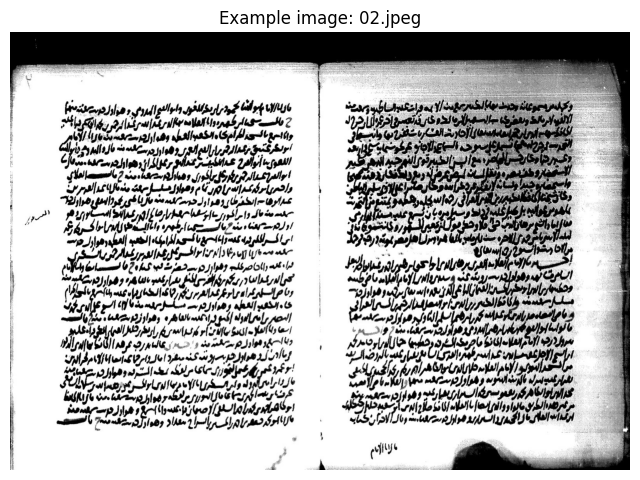

In [4]:
# Display one random example image
sample_image_id = random.choice(image_ids)
sample_image_path = os.path.join(IMAGES_DIR, sample_image_id)

sample_image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Example image: {sample_image_id}")
plt.show()


## Section 4 – Data Visualization

Let's look at several manuscript images to get familiar with the dataset before building an OCR pipeline.

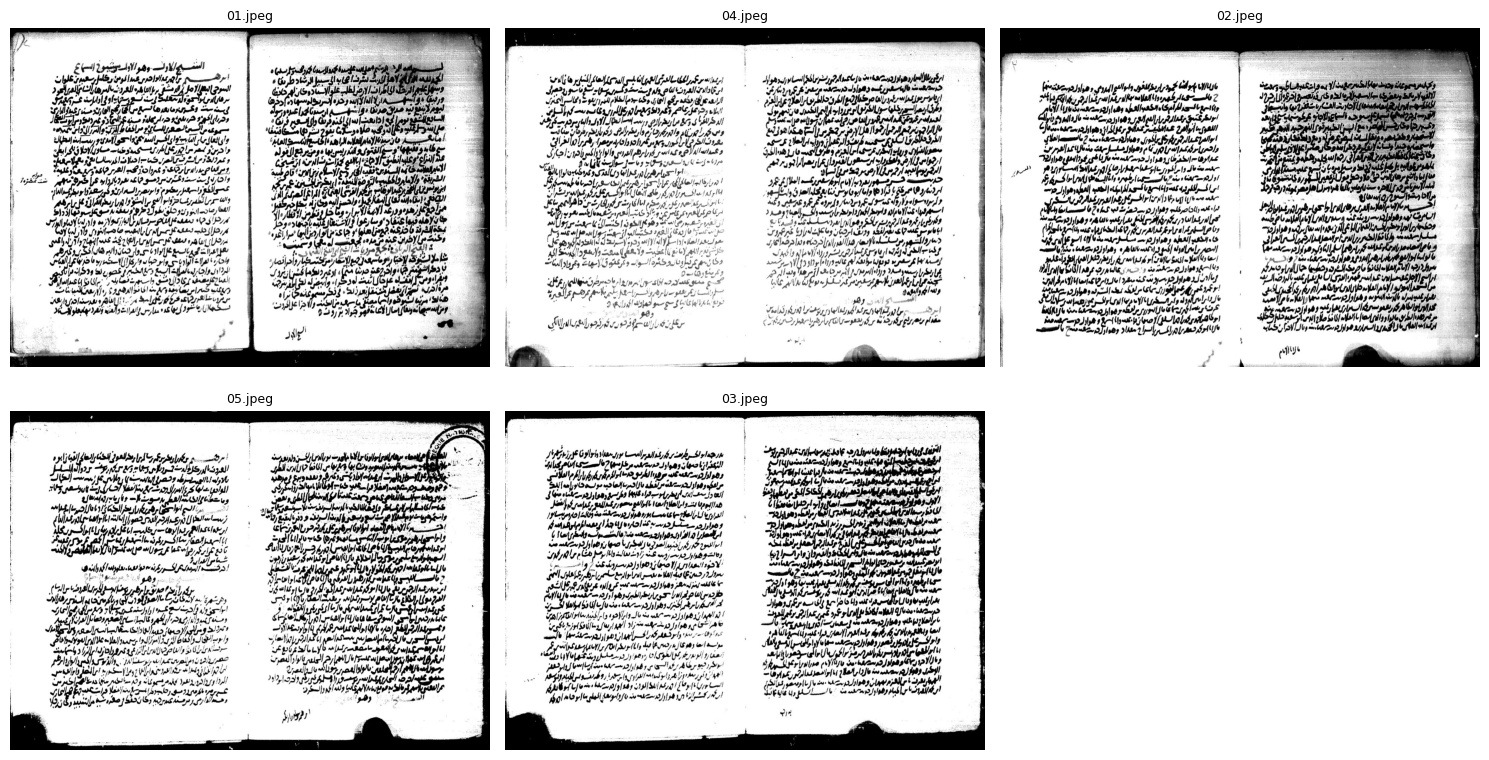

In [5]:
def show_sample_grid(image_ids, images_dir, n=6, cols=3):
    """Display a grid of n random dataset images."""
    n = min(n, len(image_ids))
    sample_ids = random.sample(image_ids, n)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, image_id in enumerate(sample_ids):
        img_path = os.path.join(images_dir, image_id)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(image_id, fontsize=9)

    plt.tight_layout()
    plt.show()

show_sample_grid(image_ids, IMAGES_DIR, n=6, cols=3)


## Section 5 – Helper Functions

General-purpose helper functions used throughout the notebook.

In [6]:
def read_image(image_path):
    """Read an image from disk and return it as a PIL Image in RGB mode."""
    return Image.open(image_path).convert("RGB")


def display_image(image, title=""):
    """Display a single PIL image with an optional title."""
    plt.figure(figsize=(6, 5))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def save_predictions(image_ids, predictions, output_path="submission.csv"):
    """Save predictions to a CSV file in the required submission format."""
    submission_df = pd.DataFrame({
        "image_id": image_ids,
        "predicted_text": [str(p).strip() for p in predictions]
    })
    submission_df.to_csv(output_path, index=False, encoding="utf-8")
    print(f"Saved {len(submission_df)} predictions to {output_path}")
    return submission_df


def load_csv(csv_path):
    """Load a CSV file with UTF-8 encoding."""
    return pd.read_csv(csv_path, encoding="utf-8")


print("Helper functions ready.")


Helper functions ready.


## Section 6 – Starter Guide

This section is for reference — it summarizes ideas for building your OCR pipeline in the next section. You are **not required** to use any of the suggestions below; you may use any OCR or Vision-Language model you prefer.

### Choosing a Model

There is no required model for this competition. The winning solution is determined by OCR accuracy (CER) on the evaluation dataset alongside other criteria. You're encouraged to research and compare OCR / Vision-Language models on Hugging Face and other open-source repositories.

architectures | Higher potential accuracy, more work required |

**Helpful resources:**
* Hugging Face Models (Image-to-Text): https://huggingface.co/models?pipeline_tag=image-to-text
* TrOCR Documentation: https://huggingface.co/docs/transformers/model_doc/trocr
* Florence-2: https://huggingface.co/microsoft/Florence-2-base
* Donut Documentation: https://huggingface.co/docs/transformers/model_doc/donut
* PaddleOCR: https://github.com/PaddlePaddle/PaddleOCR

### Tips for Improving Accuracy

* Try different pretrained OCR models (ideally ones with Arabic / multilingual support).
* Fine-tune a model if you have extra labeled data of your own.
* Apply image preprocessing (contrast enhancement, denoising, thresholding, sharpening, resizing, etc.).
* Apply text post-processing to correct common OCR mistakes.
* Compare multiple OCR models and select the best prediction per image (ensembling).
* Use a language model to refine/correct OCR output.

### Expected Workflow

```
Historical Manuscript Image
            │
            ▼
(Optional) Image Preprocessing
            │
            ▼
OCR / HTR Model
            │
            ▼
(Optional) Post-processing
            │
            ▼
Predicted Text
            │
            ▼
Generate submission.csv
```


## Section 7 – Build Your OCR Pipeline (Your Main Task)

**This is the section you should modify.**

You may implement *any* OCR pipeline you like, for example:

* Load a pretrained OCR/HTR model (e.g. TrOCR, Florence-2, PaddleOCR, Donut, Qwen2.5-VL, ...)
* Fine-tune a model
* Train a model from scratch
* Apply image preprocessing / enhancement (denoising, contrast, binarization, deskewing, ...)
* Apply text post-processing to fix common OCR mistakes
* Use a language model to refine/correct OCR output
* Combine multiple models (ensembling / voting)

The only requirement: implement a function `predict_text(image_path)` that takes the path to a single image and returns the predicted text as a string. Everything downstream calls this function automatically.

Below is a **minimal baseline** using TrOCR to get you started — feel free to replace it entirely because it uses english not arabic.

In [7]:
# ------------------------------------------------------------
# BASELINE EXAMPLE (TrOCR) — feel free to delete/replace this
# entirely with your own pipeline.
# ------------------------------------------------------------
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

_trocr_processor = None
_trocr_model = None

def _load_baseline_model():
    """Lazily load the baseline TrOCR model and processor."""
    global _trocr_processor, _trocr_model
    if _trocr_model is None:
        print("Loading baseline TrOCR model (microsoft/trocr-base-handwritten)...")
        _trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
        _trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
        _trocr_model.to(DEVICE)
        _trocr_model.eval()
        print("Baseline model loaded.")
    return _trocr_processor, _trocr_model


In [8]:
def preprocess_image(image):
    """
    (Optional) Apply any image preprocessing here, e.g. contrast
    enhancement, denoising, binarization, deskewing, resizing, etc.

    Currently a no-op — replace with your own preprocessing logic.
    """
    return image


def postprocess_text(text):
    """
    (Optional) Apply any text post-processing here, e.g. removing
    stray characters, spelling correction, language-model rescoring, etc.

    Currently a no-op — replace with your own post-processing logic.
    """
    return text.strip()


def predict_text(image_path):
    """
    Return the predicted text for a single image.

    This is the function you should improve. The baseline implementation
    below uses TrOCR out of the box, with no fine-tuning or preprocessing.

    NOTE: TrOCR's base handwritten checkpoint is trained on English text
    and is NOT specialized for Arabic — this baseline is meant only as a
    working example of the pipeline, not a strong solution. Swap in a
    stronger / Arabic-capable model to improve results.
    """
    processor, model = _load_baseline_model()

    image = read_image(image_path)
    image = preprocess_image(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(DEVICE)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    prediction = postprocess_text(prediction)

    return prediction


# Quick sanity check on a single image
_test_image_id = image_ids[0]
_test_path = os.path.join(IMAGES_DIR, _test_image_id)
print("Test prediction:", predict_text(_test_path))


Loading baseline TrOCR model (microsoft/trocr-base-handwritten)...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Baseline model loaded.


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Test prediction: the first of the first time


## Section 8 – Run Predictions

Loop through every image in the dataset and call `predict_text()`.

In [9]:
predictions = []

for image_id in image_ids:
    image_path = os.path.join(IMAGES_DIR, image_id)

    prediction = predict_text(image_path)
    predictions.append(prediction)

    print(f"{image_id}: {prediction}")

print(f"\nGenerated predictions for {len(predictions)} images.")


01.jpeg: the first of the first time
02.jpeg: 0 0
03.jpeg: 0 0
04.jpeg: 0 1
05.jpeg: 0 0

Generated predictions for 5 images.


## Section 9 – Generate Submission File

This automatically saves your predictions to `submission.csv` in the required format:

```csv
image_id,predicted_text
01.jpeg,هذا نص متوقع
02.jpeg,وهذا مثال آخر
```

Make sure the filenames in `image_id` exactly match the images in the dataset before submitting. **This is the file you should submit.**

In [10]:
submission_df = save_predictions(image_ids, predictions, output_path="submission.csv")
submission_df.head()


Saved 5 predictions to submission.csv


,image_id,predicted_text
0,01.jpeg,the first of the first time
1,02.jpeg,0 0
2,03.jpeg,0 0
3,04.jpeg,0 1
4,05.jpeg,0 0


---
### 🎉 That's it for participants!

Once `submission.csv` looks correct, submit it.